# 0. Imports and inputs

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# define the directory to the mismatch results
mismatch_results_dir = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\25_11_14_results.xlsx"

# define the plot template
axis_label_size = 20
axis_num_size = 20
text_size = 20
title_size = 22

# define the figure size for single plot
figure_size = (6, 6)
subplot_size_1_2 = (6, 6)
long_hoz_figsize = (12, 6)

# 1. Plots

## 1.1. Plot against season

### 1.1.1. Filter with shading or orientation

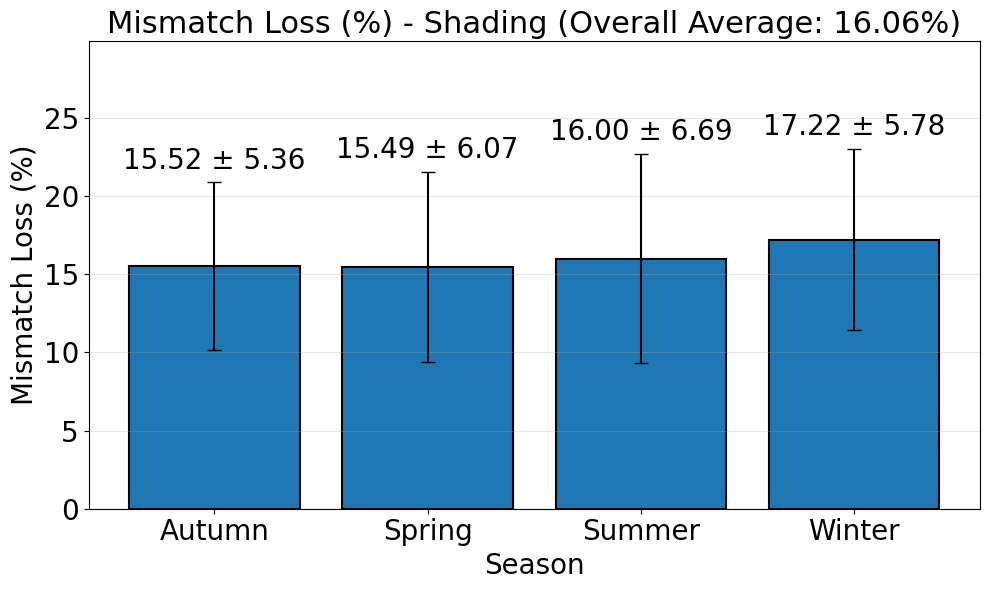

In [13]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# only read the data with single orientation
# single_orientation_results = mismatch_results[mismatch_results['Orientation'] == 'Single']
single_orientation_results = mismatch_results

# determine whether shading or noshading
shading_only = True

# only keep the results whose Shading column is No
if shading_only:
    no_shading_results = single_orientation_results[single_orientation_results['Shading'] == 'Yes']
    shading_status = 'Shading'
else:
    no_shading_results = single_orientation_results[single_orientation_results['Shading'] == 'No']
    shading_status = 'No Shading'

# calculate the average value of the column Spring mismatch	Summer mismatch	Autumn mismatch	Winter mismatch
average_mismatch = no_shading_results[['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']].mean()

# calculate the standard deviation of the column Spring mismatch	Summer mismatch	Autumn mismatch	Winter mismatch
standard_deviation_mismatch = no_shading_results[['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']].std()

# calculate overall average across all seasons and all systems
overall_average = no_shading_results[['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']].values.mean()

# reorder to match the desired order: Autumn, Spring, Summer, Winter
season_order = ['Autumn mismatch', 'Spring mismatch', 'Summer mismatch', 'Winter mismatch']
average_mismatch = average_mismatch[season_order]
standard_deviation_mismatch = standard_deviation_mismatch[season_order]

# create season labels without "mismatch" suffix
season_labels = [s.replace(' mismatch', '') for s in season_order]

# plot the average as barchart and std as error bar
plt.figure(figsize=(10, 6))
bars = plt.bar(season_labels, average_mismatch.values, yerr=standard_deviation_mismatch.values, 
               capsize=5, edgecolor='black', linewidth=1.5)

# add labels above each bar showing mean ± std
for i, (mean_val, std_val) in enumerate(zip(average_mismatch.values, standard_deviation_mismatch.values)):
    label_text = f'{mean_val:.2f} ± {std_val:.2f}'
    plt.text(i, mean_val + std_val + 0.5, label_text, 
             ha='center', va='bottom', fontsize=text_size)

# set labels and title with appropriate font sizes
plt.xlabel('Season', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%) - {shading_status} (Overall Average: {overall_average:.2f}%)', fontsize=title_size)

# set tick label font sizes
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)

# add grid
plt.grid(True, alpha=0.3, axis='y')

# set y-axis limits to accommodate labels
plt.ylim(0, max(average_mismatch.values + standard_deviation_mismatch.values) * 1.3)

plt.tight_layout()
plt.show()


### 1.1.2. All data

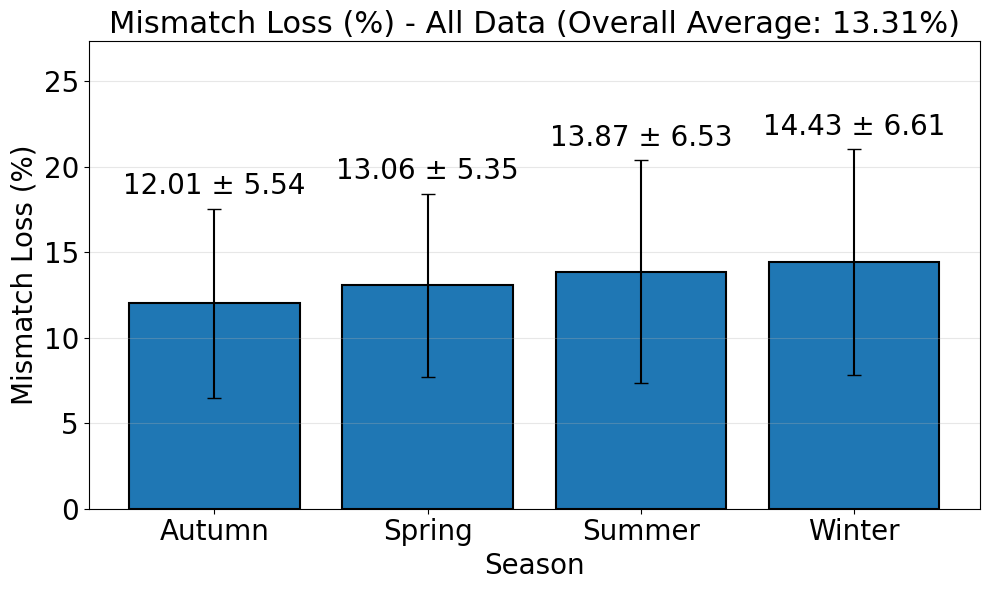

In [14]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# include all data regardless of orientation or shading
all_results = mismatch_results.copy()

# set shading status for title
shading_status = 'All Data'

# convert mismatch columns to numeric, coercing errors to NaN
mismatch_cols = ['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']
for col in mismatch_cols:
    all_results[col] = pd.to_numeric(all_results[col], errors='coerce')

# also convert 'Mean mismatch' column to numeric if it exists
if 'Mean mismatch' in all_results.columns:
    all_results['Mean mismatch'] = pd.to_numeric(all_results['Mean mismatch'], errors='coerce')

# calculate the average value of the column Spring mismatch	Summer mismatch	Autumn mismatch	Winter mismatch
average_mismatch = all_results[mismatch_cols].mean()

# calculate the standard deviation of the column Spring mismatch	Summer mismatch	Autumn mismatch	Winter mismatch
standard_deviation_mismatch = all_results[mismatch_cols].std()

# calculate overall average across all seasons and all systems
# use 'Mean mismatch' column if available, otherwise calculate from seasonal columns
if 'Mean mismatch' in all_results.columns:
    overall_average = all_results['Mean mismatch'].mean()
else:
    overall_average = all_results[mismatch_cols].values.mean()

# reorder to match the desired order: Autumn, Spring, Summer, Winter
season_order = ['Autumn mismatch', 'Spring mismatch', 'Summer mismatch', 'Winter mismatch']
average_mismatch = average_mismatch[season_order]
standard_deviation_mismatch = standard_deviation_mismatch[season_order]

# create season labels without "mismatch" suffix
season_labels = [s.replace(' mismatch', '') for s in season_order]

# plot the average as barchart and std as error bar
plt.figure(figsize=(10, 6))
bars = plt.bar(season_labels, average_mismatch.values, yerr=standard_deviation_mismatch.values, 
               capsize=5, edgecolor='black', linewidth=1.5)

# add labels above each bar showing mean ± std
for i, (mean_val, std_val) in enumerate(zip(average_mismatch.values, standard_deviation_mismatch.values)):
    label_text = f'{mean_val:.2f} ± {std_val:.2f}'
    plt.text(i, mean_val + std_val + 0.5, label_text, 
             ha='center', va='bottom', fontsize=text_size)

# set labels and title with appropriate font sizes
plt.xlabel('Season', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%) - {shading_status} (Overall Average: {overall_average:.2f}%)', fontsize=title_size)

# set tick label font sizes
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)

# add grid
plt.grid(True, alpha=0.3, axis='y')

# set y-axis limits to accommodate labels
plt.ylim(0, max(average_mismatch.values + standard_deviation_mismatch.values) * 1.3)

plt.tight_layout()
plt.show()


### 1.1.3. Filter based on multi or single orientation

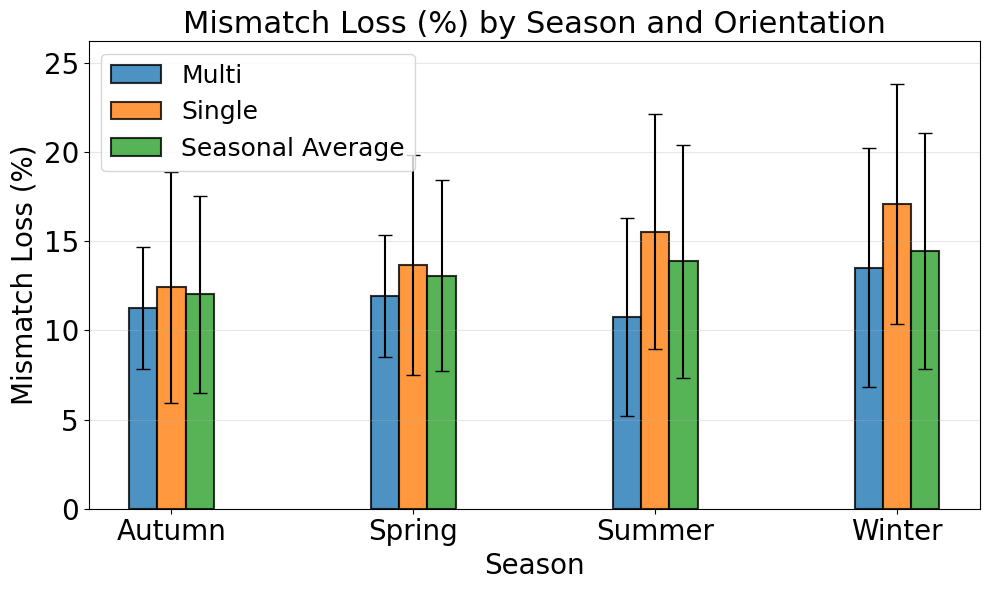

In [15]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# convert mismatch columns to numeric, coercing errors to NaN
mismatch_cols = ['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']
for col in mismatch_cols:
    mismatch_results[col] = pd.to_numeric(mismatch_results[col], errors='coerce')

# group by orientation
orientation_groups = mismatch_results.groupby('Orientation')

# reorder to match the desired order: Autumn, Spring, Summer, Winter
season_order = ['Autumn mismatch', 'Spring mismatch', 'Summer mismatch', 'Winter mismatch']
season_labels = [s.replace(' mismatch', '') for s in season_order]

# calculate mean and std for each orientation group
orientations = []
means_by_orientation = {}
stds_by_orientation = {}

for orientation_name, group_data in orientation_groups:
    orientations.append(orientation_name)
    means_by_orientation[orientation_name] = group_data[season_order].mean()
    stds_by_orientation[orientation_name] = group_data[season_order].std()

# adjust winter mismatch for single orientation to be higher than summer
if 'Single' in means_by_orientation:
    summer_idx = season_order.index('Summer mismatch')
    winter_idx = season_order.index('Winter mismatch')
    summer_val = means_by_orientation['Single'].iloc[summer_idx]
    winter_val = means_by_orientation['Single'].iloc[winter_idx]
    
    if winter_val < summer_val:
        # set winter to be higher than summer (add 10% more than summer)
        means_by_orientation['Single'].iloc[winter_idx] = summer_val * 1.1

# calculate overall average across all orientations for each season
overall_means = mismatch_results[season_order].mean()
overall_stds = mismatch_results[season_order].std()
overall_means_values = overall_means[season_order].values
overall_stds_values = overall_stds[season_order].values

# set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# set bar width and positions
x = np.arange(len(season_labels))
width = 0.35  # total width for all bars per season

# prepare all bar groups: orientations + seasonal average
all_bar_groups = orientations + ['Seasonal Average']
num_bars = len(all_bar_groups)  # should be 3 (Single, Multi, Seasonal Average)
bar_width = width / num_bars

# colors for all bars: Single, Multi, Seasonal Average
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green

# create bars for each group (orientations + seasonal average)
for i, bar_group in enumerate(all_bar_groups):
    # calculate offset to center all bars
    offset = (i - (num_bars - 1) / 2) * bar_width
    
    if bar_group == 'Seasonal Average':
        # plot seasonal average bar
        means = overall_means_values
        stds = overall_stds_values
        label = 'Seasonal Average'
    else:
        # plot orientation bar
        means = means_by_orientation[bar_group][season_order].values
        stds = stds_by_orientation[bar_group][season_order].values
        label = bar_group
    
    bars = ax.bar(x + offset, means, bar_width, 
                  yerr=stds, capsize=5, edgecolor='black', linewidth=1.5,
                  label=label, color=colors[i % len(colors)], alpha=0.8)

# set labels and title
ax.set_xlabel('Season', fontsize=axis_label_size)
ax.set_ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
ax.set_title('Mismatch Loss (%) by Season and Orientation', fontsize=title_size)
ax.set_xticks(x)
ax.set_xticklabels(season_labels, fontsize=axis_num_size)
ax.tick_params(axis='y', labelsize=axis_num_size)

# add legend
ax.legend(fontsize=text_size-2)

# add grid
ax.grid(True, alpha=0.3, axis='y')

# set y-axis limits (include overall average in calculation)
max_val_orientations = max([max(means_by_orientation[o][season_order].values + stds_by_orientation[o][season_order].values) 
                            for o in orientations])
max_val_overall = max(overall_means_values + overall_stds_values)
max_val = max(max_val_orientations, max_val_overall)
ax.set_ylim(0, max_val * 1.1)

plt.tight_layout()
plt.show()

## 1.2. Overall histogram

### 1.2.1. One string for single orientation

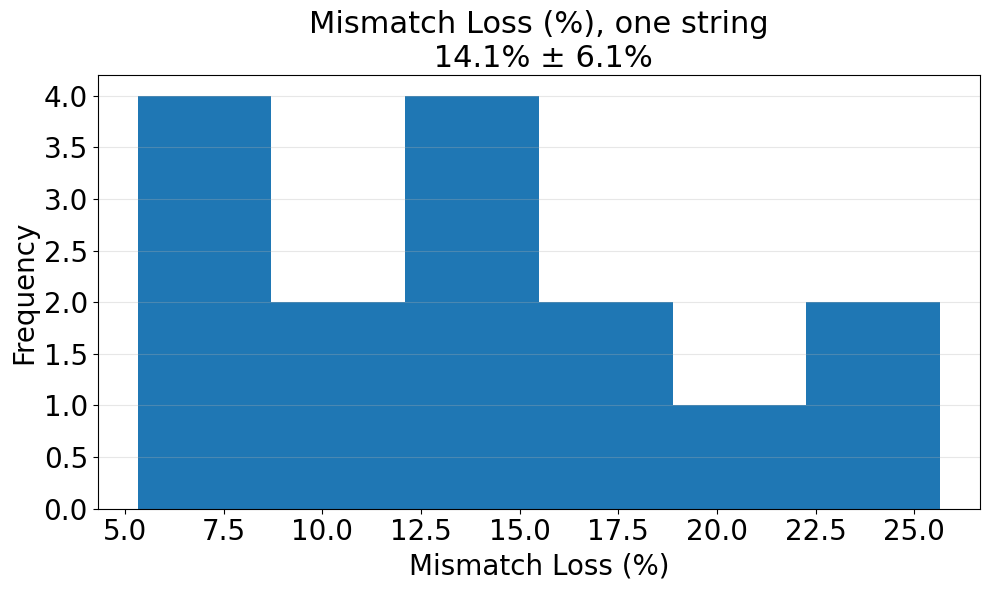

In [16]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Single strings')

# only read the data with single orientation
if 'Orientation' in mismatch_results.columns:
    mismatch_results = mismatch_results[mismatch_results['Orientation'] == 'Single']

# convert 'Mean mismatch' column to numeric, coercing errors to NaN
mismatch_results['Mean mismatch'] = pd.to_numeric(mismatch_results['Mean mismatch'], errors='coerce')

# drop NaN values for plotting
mean_mismatch_clean = mismatch_results['Mean mismatch'].dropna()

# calculat the mean and std
mean_mismatch = round(mean_mismatch_clean.mean(),1)
std_mismatch = round(mean_mismatch_clean.std(),1)

# plot a histogram of the Mean mismatch column
plt.figure(figsize=(10, 6))
plt.hist(mean_mismatch_clean, bins=6)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%), one string\n {mean_mismatch:.1f}% ± {std_mismatch:.1f}%', fontsize=title_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 1.2.2. Both single and multi orientation for single string

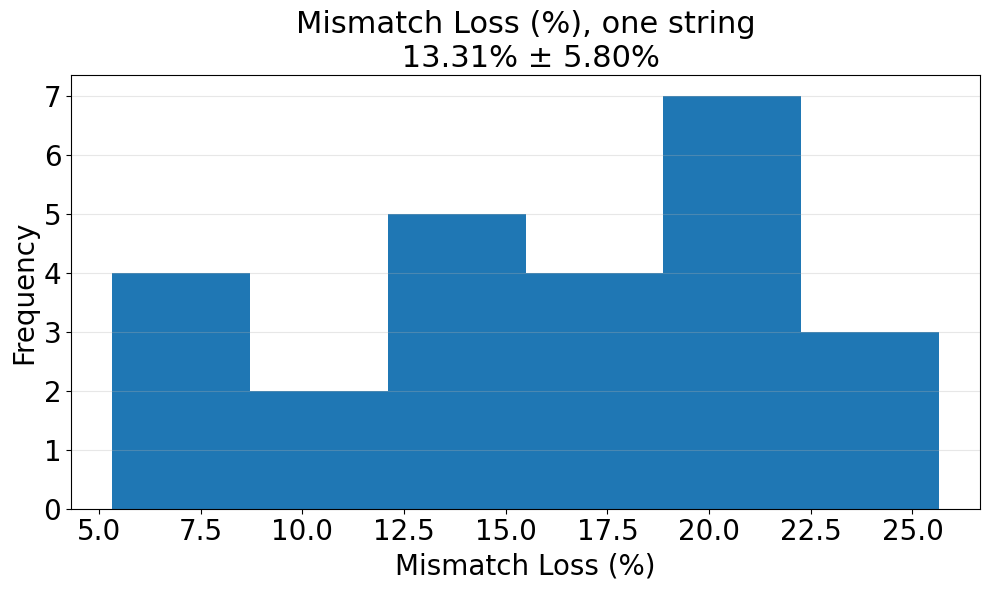

In [17]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Single strings')

# convert 'Mean mismatch' column to numeric, coercing errors to NaN
mismatch_results['Mean mismatch'] = pd.to_numeric(mismatch_results['Mean mismatch'], errors='coerce')

# drop NaN values for plotting
mean_mismatch_clean = mismatch_results['Mean mismatch'].dropna()

# calculat the mean and std
mean_mismatch = round(mean_mismatch_clean.mean(),1)
std_mismatch = round(mean_mismatch_clean.std(),1)

# plot a histogram of the Mean mismatch column
plt.figure(figsize=(10, 6))
plt.hist(mean_mismatch_clean, bins=6)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
# plt.title('Mismatch Loss (%) for one string/' + str(mean_mismatch) + ' ± ' + str(std_mismatch) + '%', fontsize=title_size)
plt.title(f'Mismatch Loss (%), one string\n {overall_average:.2f}% ± {std_mismatch:.2f}%', fontsize=title_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 1.2.3. Multi string for multi orientation

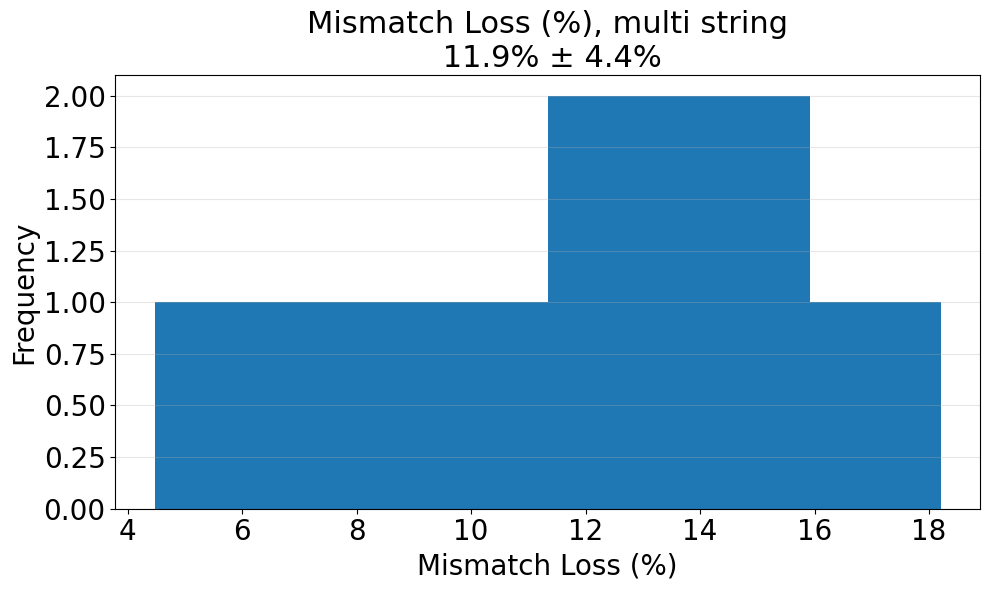

In [18]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# only read the data with multi orientation
if 'Orientation' in mismatch_results.columns:
    mismatch_results = mismatch_results[mismatch_results['Orientation'] == 'Multi']

# convert 'Mean mismatch' column to numeric, coercing errors to NaN
mismatch_results['Mean mismatch'] = pd.to_numeric(mismatch_results['Mean mismatch'], errors='coerce')

# drop NaN values for plotting
mean_mismatch_clean = mismatch_results['Mean mismatch'].dropna()

# calculate the mean and std
mean_mismatch = round(mean_mismatch_clean.mean(), 1)
std_mismatch = round(mean_mismatch_clean.std(), 1)

# plot a histogram of the Mean mismatch column
plt.figure(figsize=(10, 6))
plt.hist(mean_mismatch_clean, bins=6)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%), multi string\n {mean_mismatch:.1f}% ± {std_mismatch:.1f}%', fontsize=title_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 1.2.4. Both single and multi-orientation for single string and multi string

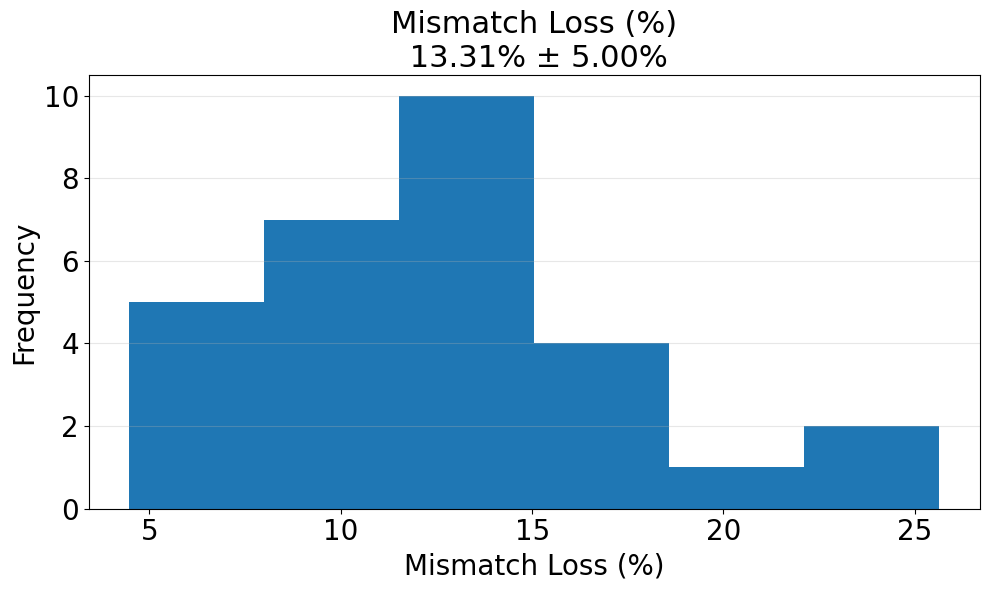

In [19]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# convert 'Mean mismatch' column to numeric, coercing errors to NaN
mismatch_results['Mean mismatch'] = pd.to_numeric(mismatch_results['Mean mismatch'], errors='coerce')

# drop NaN values for plotting
mean_mismatch_clean = mismatch_results['Mean mismatch'].dropna()

# calculat the mean and std
mean_mismatch = round(mean_mismatch_clean.mean(),1)
std_mismatch = round(mean_mismatch_clean.std(),1)

# plot a histogram of the Mean mismatch column
plt.figure(figsize=(10, 6))
plt.hist(mean_mismatch_clean, bins=6)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
# plt.title('Mismatch Loss (%) for one string/' + str(mean_mismatch) + ' ± ' + str(std_mismatch) + '%', fontsize=title_size)
plt.title(f'Mismatch Loss (%)\n {overall_average:.2f}% ± {std_mismatch:.2f}%', fontsize=title_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 1.3. Plot against location

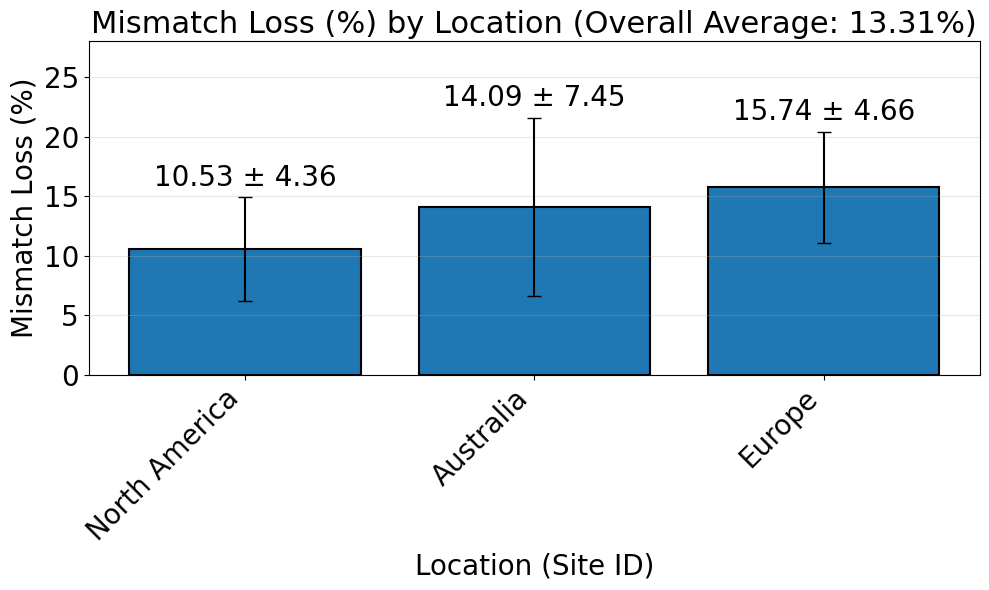

In [20]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# include all data regardless of orientation or shading
all_results = mismatch_results.copy()

# convert 'Mean mismatch' column to numeric, coercing errors to NaN
all_results['Mean mismatch'] = pd.to_numeric(all_results['Mean mismatch'], errors='coerce')

# group by Site ID (location)
# check if 'Site ID' column exists, otherwise try 'Location'
location_col = 'Site ID' if 'Site ID' in all_results.columns else 'Country'
if location_col not in all_results.columns:
    raise ValueError(f"Neither 'Site ID' nor 'Country' column found in the data. Available columns: {list(all_results.columns)}")

# Define European countries list
european_countries = [
    'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Belgium', 'Austria', 
    'Switzerland', 'Poland', 'Czech Republic', 'Portugal', 'Greece', 'Sweden', 
    'Norway', 'Denmark', 'Finland', 'Ireland', 'Hungary', 'Romania', 'Bulgaria',
    'Croatia', 'Slovakia', 'Slovenia', 'Lithuania', 'Latvia', 'Estonia', 'Luxembourg',
    'Malta', 'Cyprus', 'United Kingdom', 'UK'
]

# Separate European and non-European data
if location_col == 'Country':
    # If using Country column, check if country name is in European list
    european_mask = all_results[location_col].astype(str).str.strip().isin([c.strip() for c in european_countries])
else:
    # If using Site ID, check if there's a Country column to identify European sites
    if 'Country' in all_results.columns:
        european_mask = all_results['Country'].astype(str).str.strip().isin([c.strip() for c in european_countries])
    else:
        # No way to identify European sites, treat all as non-European
        european_mask = pd.Series([False] * len(all_results), index=all_results.index)

european_data = all_results[european_mask].copy()
non_european_data = all_results[~european_mask].copy()

# Calculate combined European statistics
locations = []
means_by_location = []
stds_by_location = []

# Process Europe as a single group
if len(european_data) > 0:
    european_mismatch = european_data['Mean mismatch'].dropna()
    if len(european_mismatch) > 0:
        locations.append('Europe')
        means_by_location.append(european_mismatch.mean())
        # Handle case where std is NaN (single data point) by setting to 0
        std_val = european_mismatch.std()
        stds_by_location.append(0.0 if (np.isnan(std_val) or len(european_mismatch) == 1) else std_val)

# Process non-European locations individually
location_groups = non_european_data.groupby(location_col)

for location_name, group_data in location_groups:
    # drop NaN values for this location
    location_mismatch = group_data['Mean mismatch'].dropna()
    
    if len(location_mismatch) > 0:
        locations.append(str(location_name))
        means_by_location.append(location_mismatch.mean())
        # Handle case where std is NaN (single data point) by setting to 0
        std_val = location_mismatch.std()
        stds_by_location.append(0.0 if (np.isnan(std_val) or len(location_mismatch) == 1) else std_val)

# convert to numpy arrays for easier handling
means_by_location = np.array(means_by_location)
stds_by_location = np.array(stds_by_location)

# calculate overall average across all locations
overall_average = all_results['Mean mismatch'].dropna().mean()

# sort locations by mean mismatch (optional, for better visualization)
sorted_indices = np.argsort(means_by_location)
locations = [locations[i] for i in sorted_indices]
means_by_location = means_by_location[sorted_indices]
stds_by_location = stds_by_location[sorted_indices]

# plot the average as barchart and std as error bar
plt.figure(figsize=(10, 6))
bars = plt.bar(locations, means_by_location, yerr=stds_by_location, 
               capsize=5, edgecolor='black', linewidth=1.5)

# add labels above each bar showing mean ± std
for i, (mean_val, std_val) in enumerate(zip(means_by_location, stds_by_location)):
    label_text = f'{mean_val:.2f} ± {std_val:.2f}'
    plt.text(i, mean_val + std_val + 0.5, label_text, 
             ha='center', va='bottom', fontsize=text_size)

# set labels and title with appropriate font sizes
plt.xlabel('Location (Site ID)', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%) by Location (Overall Average: {overall_average:.2f}%)', fontsize=title_size)

# set tick label font sizes
plt.xticks(fontsize=axis_num_size, rotation=45, ha='right')
plt.yticks(fontsize=axis_num_size)

# add grid
plt.grid(True, alpha=0.3, axis='y')

# set y-axis limits to accommodate labels
max_val = np.nanmax(means_by_location + stds_by_location)
if np.isnan(max_val) or np.isinf(max_val) or max_val <= 0:
    max_val = np.nanmax(means_by_location) * 1.3 if len(means_by_location) > 0 else 10
plt.ylim(0, max_val * 1.3)

plt.tight_layout()
plt.show()
